In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

import ladder
plt.close()

In [3]:
# from download.weka import pull_predictions_from_weka
# pull_predictions_from_weka("consistent_ranking")

# from download.hf import pull_predictions_from_hf
# pull_predictions_from_hf("davidheineman/consistent-ranking-evals", "consistent_ranking")

In [4]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']

# COLS += ['acc_per_char', 'correct_choice'] # accuracy benchmarks
# COLS += ['logits_per_byte', 'logits_per_byte_corr', 'logits_per_char_corr']

COLS += ['acc_per_char'] # accuracy benchmarks
COLS += ['logits_per_byte_corr']

# df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)
df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_final_predictions.parquet', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

Loaded 206,118,549 instance predictions


In [41]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

MMLU  = [t for t in TASKS if 'mmlu' in t]
TASKS = [t for t in TASKS if 'mmlu' not in t and ':para' not in t]
TASKS = sorted(TASKS)

In [6]:
ladder_config_path = f'{ROOT_DIR}/analysis/notebooks/ladder_configs/cheap_decisions.json'
ladder_config_path_no_750m = f'{ROOT_DIR}/analysis/notebooks/ladder_configs/cheap_decisions_no_750m.json'

In [46]:
# From: https://github.com/allenai/oe-eval-internal/blob/eval-for-consistent-ranking/experiments/eval-for-consistent-ranking/metrics/project/data_exploration_and_cleaning.ipynb
MIXES = [
    'DCLM-baseline',
    'c4',
    'dclm_ft7percentile_fw2',
    'dclm_ft7percentile_fw3',
    'dclm_fw_top10',
    'dclm_fw_top3',
    'dolma-v1-6-and-sources-baseline',
    'dolma17',
    'dolma17-25p-DCLM-baseline-75p',
    'dolma17-50p-DCLM-baseline-50p',
    'dolma17-75p-DCLM-baseline-25p',
    'falcon',
    'falcon_and_cc',
    'falcon_and_cc_eli5_oh_top10p',
    'falcon_and_cc_eli5_oh_top20p',
    'falcon_and_cc_og_eli5_oh_top10p',
    'falcon_and_cc_tulu_qc_top10',
    'fineweb_edu_dedup',
    'no_code',
    'no_flan',
    'no_math_no_code',
    'no_reddit',
    'pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top10p',
    'pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top20p',
    'prox_fineweb_pro'
]

### Model Ladder Example

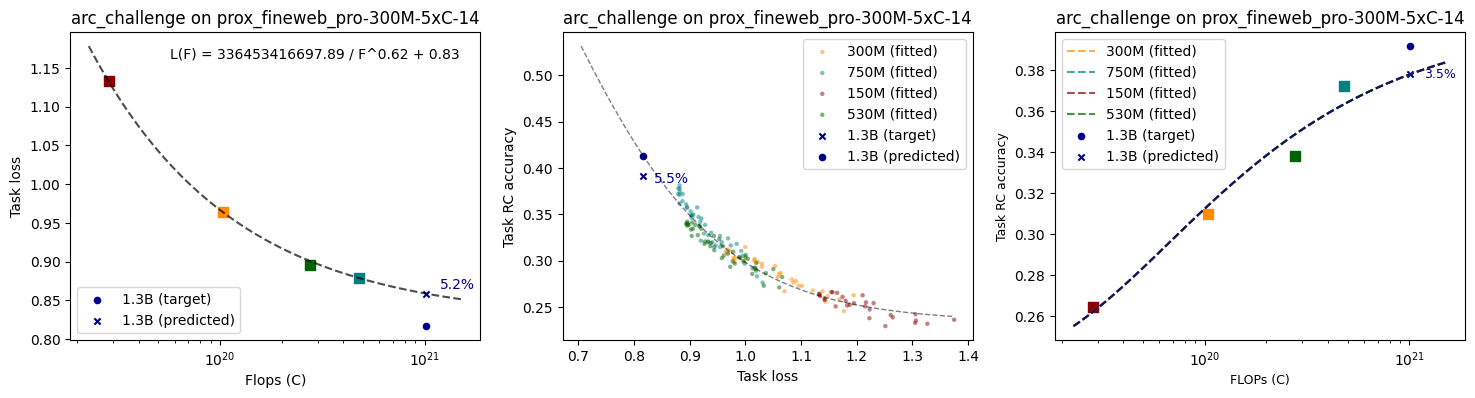

In [16]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]

train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=train_models,
    eval_models=eval_models,
    config_path=ladder_config_path,
    use_flops=True,
    axes=axes[0],
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

Fitting model ladder predictions: 100%|██████████| 9/9 [00:23<00:00,  2.57s/it]


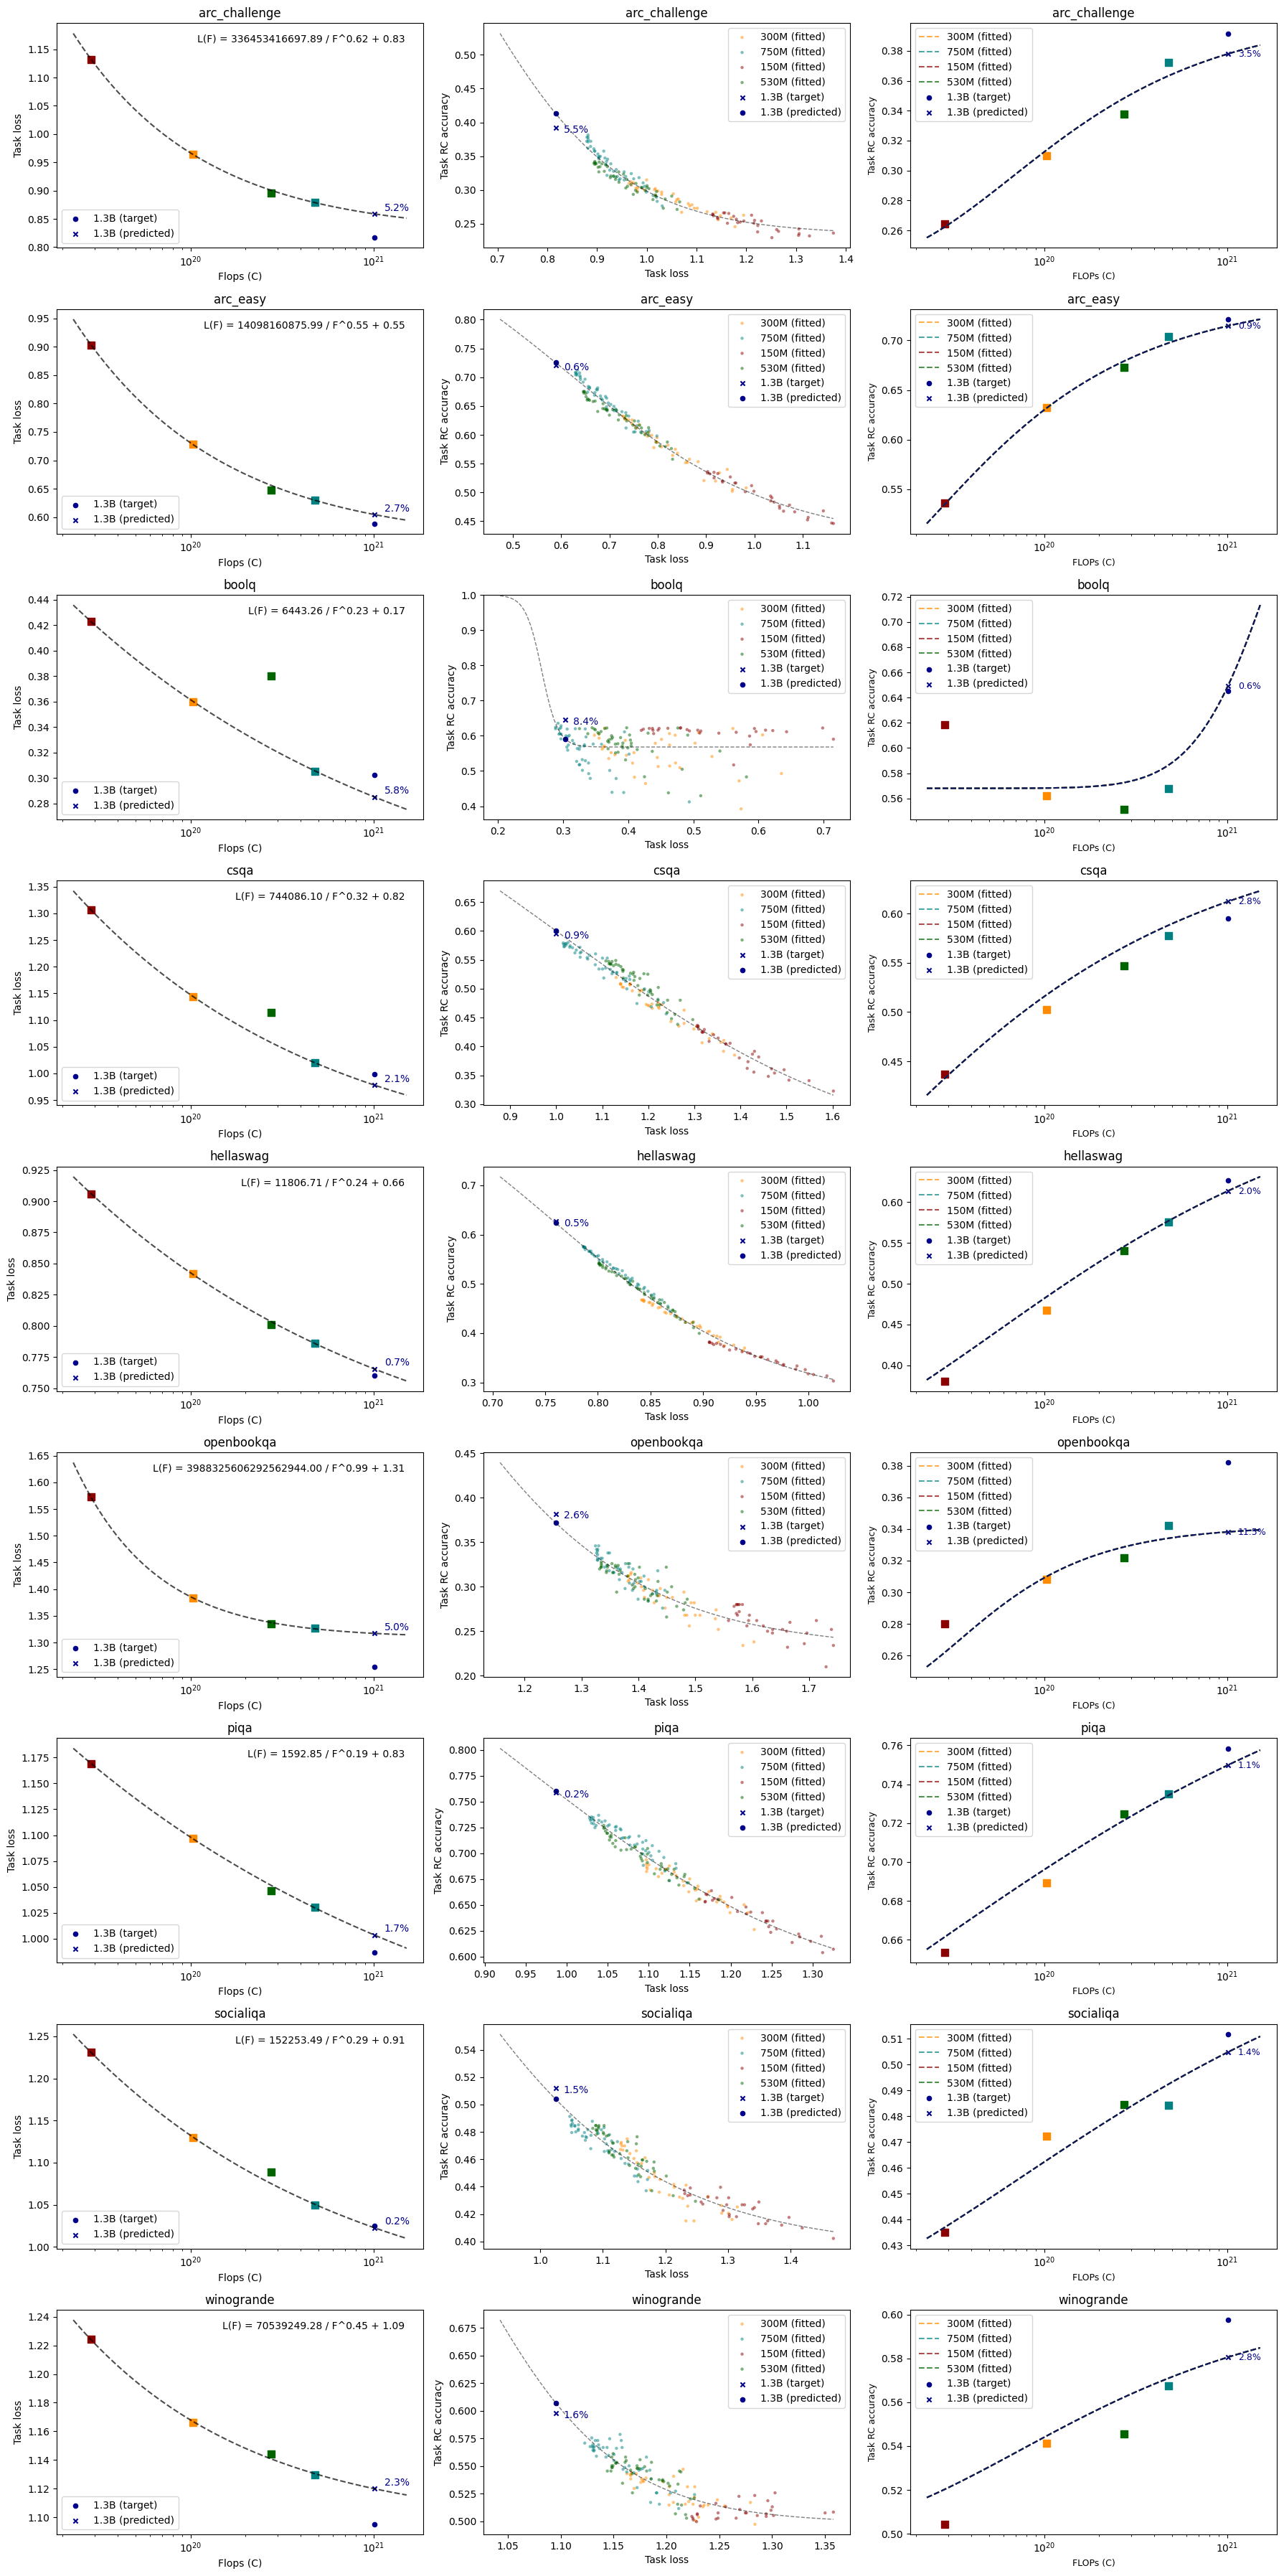

In [17]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
    _, _, _ = run_ladder(
        df,
        task_name=task,
        train_models=train_models,
        eval_models=eval_models,
        config_path=ladder_config_path,
        use_flops=True,
        axes=axes[i],
    )

fig.tight_layout()

### Model Ladder with 750M model

In [47]:
from tqdm import tqdm

fitting_results_step_1 = pd.DataFrame(index=[], columns=TASKS)
fitting_results_step_2 = pd.DataFrame(index=[], columns=TASKS)
stacked_y_preds = pd.DataFrame(index=[], columns=TASKS)

for mix in tqdm(MIXES, desc='Fitting model ladder predictions', total=len(MIXES)):
    # models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]
    models = [model for model in MODELS if '-'.join(model.split('-')[:-3]) == mix]

    for i, task in enumerate(TASKS):
        train_models, eval_models = [m for m in models if '1B' not in m], [m for m in models if '1B' in m]
        try:
            (rel_error_step_1, rel_error_step_2, _), (step_1_y_pred, step_2_y_pred, stacked_y_pred) = run_ladder(
                df,
                task_name=task,
                train_models=train_models,
                eval_models=eval_models,
                config_path=ladder_config_path,
                use_flops=True,
                return_preds=True
            )
        except Exception as e:
            rel_error_step_1, rel_error_step_2, stacked_y_pred = float('inf'), float('inf'), float('inf')
            print(f'Failed on task={task}, mix={mix}')

        fitting_results_step_1.loc[mix, task] = rel_error_step_1
        fitting_results_step_2.loc[mix, task] = rel_error_step_2
        stacked_y_preds.loc[mix, task] = stacked_y_pred

Fitting model ladder predictions:   8%|▊         | 2/25 [00:48<09:16, 24.18s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:50: RuntimeWarning: overflow encountered in exp
  return np.exp(p[0]) / x ** p[1] + p[2]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:54: RuntimeWarning: overflow encountered in exp
  grad_a = np.exp(p[0]) / x ** p[1]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:55: RuntimeWarning: overflow encountered in exp
  grad_alpha = np.exp(p[0]) * (-np.log(x)) / x ** p[1]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:416: RuntimeWarning: invalid value encountered in scalar divide
  grad_us = [u if np.abs(u) < delta else (delta * np.abs(u) / u) for u in us]
Fitting model ladder predictions:  28%|██▊       | 7/25 [02:50<07:17, 24.31s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_law

In [48]:
print(f'Relative unsigned error for prediticting 1B-5xC (step 1):')
fitting_results_step_1['avg_error'] = fitting_results_step_1.mean(axis=1)
fitting_results_step_1 = fitting_results_step_1.abs()
fitting_results_step_1 = fitting_results_step_1.sort_values(by='avg_error', ascending=False)
fitting_results_step_1_display = fitting_results_step_1.map(lambda x: f'{round(x*100, 1)}%')
display(fitting_results_step_1_display)

print(f'Relative unsigned error for prediticting 1B-5xC (step 2):')
fitting_results_step_2['avg_error'] = fitting_results_step_2.mean(axis=1)
fitting_results_step_2 = fitting_results_step_2.abs()
fitting_results_step_2 = fitting_results_step_2.sort_values(by='avg_error', ascending=False)
fitting_results_step_2_display = fitting_results_step_2.map(lambda x: f'{round(x*100, 1)}%')
display(fitting_results_step_2_display)

Relative unsigned error for prediticting 1B-5xC (step 1):


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,avg_error
pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top20p,19.5%,28.6%,27.6%,24.4%,11.6%,7.7%,11.0%,10.5%,6.1%,16.3%
pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top10p,19.0%,25.5%,6.8%,26.7%,10.7%,10.8%,10.2%,9.6%,7.9%,14.1%
no_code,1.0%,6.3%,75.8%,24.9%,0.3%,7.7%,3.1%,21.2%,1.2%,11.3%
dclm_fw_top10,9.8%,9.3%,31.4%,12.2%,6.9%,4.9%,6.3%,7.2%,4.4%,10.3%
dolma17,1.1%,5.5%,48.7%,15.9%,1.0%,8.5%,0.9%,23.8%,0.2%,10.0%
dolma17-75p-DCLM-baseline-25p,2.4%,0.9%,40.6%,15.0%,1.0%,1.8%,1.2%,29.2%,1.3%,9.3%
dolma17-50p-DCLM-baseline-50p,1.8%,0.7%,67.5%,5.5%,0.3%,3.1%,2.3%,0.6%,1.2%,7.2%
fineweb_edu_dedup,17.2%,1.0%,29.1%,3.8%,0.2%,0.6%,0.9%,1.8%,0.1%,5.6%
no_math_no_code,10.7%,18.4%,34.5%,12.3%,1.4%,10.0%,9.2%,17.8%,1.7%,5.2%
dclm_ft7percentile_fw2,0.6%,27.8%,12.7%,0.3%,0.5%,0.5%,0.4%,0.4%,0.7%,4.5%


Relative unsigned error for prediticting 1B-5xC (step 2):


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,avg_error
no_code,18.1%,18.9%,11.1%,28.6%,0.8%,15.2%,1.9%,8.3%,2.4%,11.7%
dolma17,17.8%,16.9%,13.5%,10.2%,0.5%,17.7%,1.8%,7.9%,7.8%,10.3%
no_math_no_code,20.8%,14.4%,7.4%,20.3%,0.5%,18.6%,1.9%,7.5%,1.2%,10.2%
no_reddit,14.0%,13.6%,14.2%,22.1%,0.4%,0.9%,1.2%,4.4%,2.8%,7.5%
dolma17-75p-DCLM-baseline-25p,10.2%,3.4%,10.9%,25.7%,1.2%,3.0%,1.1%,16.9%,1.2%,7.3%
dolma-v1-6-and-sources-baseline,3.7%,6.3%,21.2%,14.0%,0.5%,15.9%,0.6%,10.9%,3.8%,6.6%
dolma17-50p-DCLM-baseline-50p,2.8%,0.1%,15.6%,12.2%,1.7%,3.4%,0.6%,4.7%,2.8%,3.4%
pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top10p,12.9%,1.5%,1.7%,7.9%,1.9%,3.2%,0.6%,7.0%,4.7%,2.4%
pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top20p,3.4%,0.4%,1.6%,2.4%,1.5%,11.7%,0.2%,2.0%,5.9%,1.8%
falcon_and_cc_og_eli5_oh_top10p,6.4%,1.3%,2.9%,3.4%,1.2%,6.9%,0.5%,1.9%,5.1%,1.8%


In [49]:
print('Predicted performance for 1B-5xC on all mixes:')
stacked_y_preds['macro_avg'] = stacked_y_preds.mean(axis=1)
stacked_y_preds = stacked_y_preds.sort_values(by='macro_avg', ascending=False)
stacked_y_preds_display = stacked_y_preds.map(lambda x: f'{round(x * 100, 1)}%')
stacked_y_preds_display

Predicted performance for 1B-5xC on all mixes:


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,macro_avg
falcon_and_cc_eli5_oh_top10p,43.0%,74.0%,73.3%,61.9%,63.9%,38.7%,75.7%,46.2%,60.5%,59.7%
falcon_and_cc,35.9%,66.7%,90.6%,59.6%,61.0%,34.8%,75.1%,50.4%,58.4%,59.2%
falcon_and_cc_eli5_oh_top20p,40.4%,70.9%,65.4%,64.6%,63.2%,37.6%,75.3%,53.4%,60.7%,59.1%
falcon_and_cc_og_eli5_oh_top10p,43.5%,74.0%,63.6%,64.7%,63.9%,39.1%,73.8%,51.8%,55.5%,58.9%
DCLM-baseline,38.3%,70.8%,66.8%,63.0%,62.5%,37.0%,74.1%,52.4%,62.7%,58.6%
dclm_ft7percentile_fw2,43.9%,67.9%,63.7%,64.3%,59.4%,39.3%,74.7%,53.1%,58.7%,58.3%
dolma17-25p-DCLM-baseline-75p,37.1%,71.2%,63.1%,62.9%,61.6%,36.7%,74.7%,52.6%,61.3%,57.9%
dclm_ft7percentile_fw3,46.8%,78.5%,60.8%,61.4%,54.3%,39.2%,71.4%,48.7%,55.2%,57.4%
prox_fineweb_pro,37.8%,71.5%,64.9%,61.2%,61.4%,33.8%,75.0%,50.5%,58.1%,57.1%
falcon,31.7%,65.7%,69.9%,58.3%,61.5%,33.0%,74.0%,52.2%,58.7%,56.1%


### Predict without 750M point

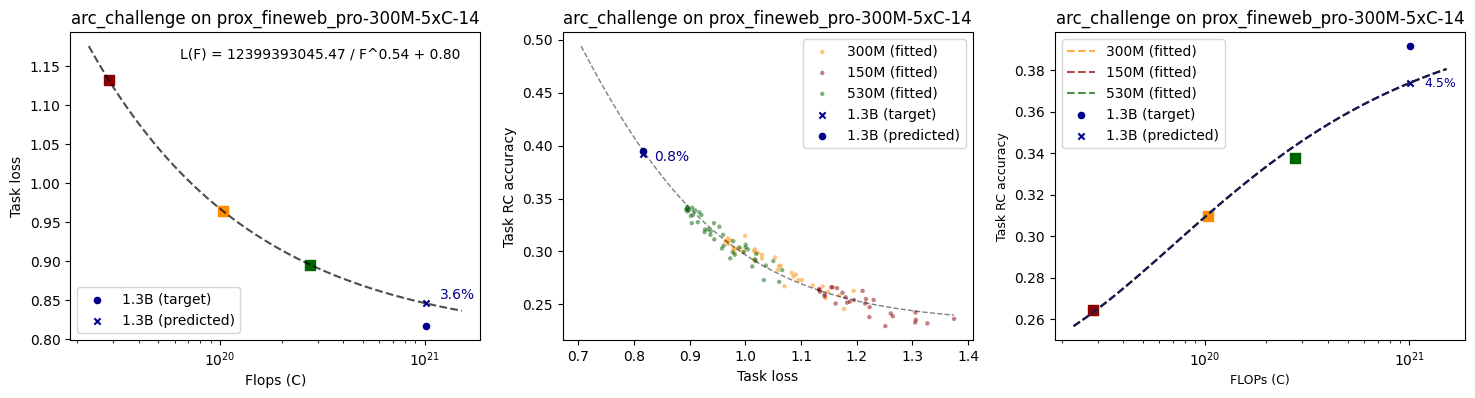

In [50]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]

train_models, eval_models = [m for m in example_models if '1B' not in m and '750M' not in m], [m for m in example_models if '1B' in m]
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=train_models,
    eval_models=eval_models,
    config_path=ladder_config_path_no_750m,
    use_flops=True,
    axes=axes[0]
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

In [51]:
from tqdm import tqdm

fitting_results_step_1_no_750m = pd.DataFrame(index=[], columns=TASKS)
fitting_results_step_2_no_750m = pd.DataFrame(index=[], columns=TASKS)
stacked_y_preds_no_750m = pd.DataFrame(index=[], columns=TASKS)

for mix in tqdm(MIXES, desc='Fitting model ladder predictions', total=len(MIXES)):
    # models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]
    models = [model for model in MODELS if '-'.join(model.split('-')[:-3]) == mix]

    for i, task in enumerate(TASKS):
        train_models, eval_models = [m for m in models if '1B' not in m and '750M' not in m], [m for m in models if '1B' in m]

        try:
            (rel_error_step_1, rel_error_step_2, _), (step_1_y_pred, step_2_y_pred, stacked_y_pred) = run_ladder(
                df,
                task_name=task,
                train_models=train_models,
                eval_models=eval_models,
                config_path=ladder_config_path_no_750m,
                use_flops=True,
                return_preds=True
            )
        except Exception as e:
            rel_error_step_1, rel_error_step_2, stacked_y_pred = float('inf'), float('inf'), float('inf')
            print(f'Failed on task={task}, mix={mix}')

        fitting_results_step_1_no_750m.loc[mix, task] = rel_error_step_1
        fitting_results_step_2_no_750m.loc[mix, task] = rel_error_step_2
        stacked_y_preds_no_750m.loc[mix, task] = stacked_y_pred

Fitting model ladder predictions:  72%|███████▏  | 18/25 [05:41<02:13, 19.03s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
Fitting model ladder predictions:  80%|████████  | 20/25 [06:18<01:34, 18.82s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
Fitting model ladder predictions: 100%|██████████| 25/25 [07:52<00:00, 18.91s/it]


In [52]:
print('Predicted performance for 1B-5xC (without using 750M) on all mixes:')
stacked_y_preds_no_750m['macro_avg'] = stacked_y_preds_no_750m.mean(axis=1)
stacked_y_preds_no_750m = stacked_y_preds_no_750m.sort_values(by='macro_avg', ascending=False)
stacked_y_preds_no_750m_display = stacked_y_preds_no_750m.map(lambda x: f'{round(x * 100, 1)}%')
stacked_y_preds_no_750m_display

Predicted performance for 1B-5xC (without using 750M) on all mixes:


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,macro_avg
falcon_and_cc_eli5_oh_top10p,44.8%,75.9%,79.5%,64.4%,64.7%,46.0%,75.6%,58.0%,62.8%,63.5%
DCLM-baseline,40.7%,74.2%,86.1%,61.1%,63.4%,33.2%,74.6%,51.4%,67.9%,61.4%
falcon_and_cc,36.7%,68.6%,97.1%,59.9%,62.5%,36.2%,75.3%,49.9%,58.6%,60.5%
dclm_ft7percentile_fw2,45.2%,78.3%,64.4%,64.7%,59.6%,40.9%,75.0%,54.5%,59.8%,60.3%
falcon_and_cc_og_eli5_oh_top10p,42.9%,74.7%,66.5%,65.5%,63.9%,40.7%,73.1%,53.0%,59.3%,60.0%
falcon_and_cc_eli5_oh_top20p,42.1%,70.3%,64.4%,65.0%,62.0%,38.0%,75.6%,53.6%,61.2%,59.1%
fineweb_edu_dedup,42.5%,74.0%,62.8%,61.7%,59.9%,40.4%,74.2%,50.6%,55.8%,58.0%
dclm_fw_top10,47.7%,75.9%,61.1%,64.0%,53.2%,37.2%,72.7%,49.5%,57.4%,57.6%
dolma17-25p-DCLM-baseline-75p,39.2%,72.9%,57.4%,63.7%,62.9%,36.1%,74.3%,51.3%,58.1%,57.3%
dclm_ft7percentile_fw3,49.4%,78.1%,60.0%,60.4%,56.0%,35.5%,72.0%,49.6%,54.9%,57.3%


### Export Data

In [53]:
# Export predictions of 1B performance with/without 750M data-point
stacked_y_preds.to_csv(f'{DATA_DIR}/cheap_decisions_stacked_rc_pred.csv')
stacked_y_preds_no_750m.to_csv(f'{DATA_DIR}/cheap_decisions_stacked_rc_pred_no_750m.csv')